In [1]:
from trot.config import configure_once

configure_once()  # float64 for the GMPS conversion

import numpy as np
from pyblock3.algebra.core import SparseTensor, SubTensor
from pyblock3.algebra.mpe import MPE
from pyblock3.algebra.mps import MPS
from pyblock3.algebra.symmetry import SZ
from pyscf import ao2mo, gto, scf

from trot.gmps.dmrg import hubbard_pyblock3_mpo, make_pyblock3_hamiltonian
from trot.gmps.utils import sd_to_gmps

L, U, t = 4, 8.0, 1.0
N = L * L
n_up = n_dn = N // 2 - 1
E_fci = -10.1218936956  # fci_4x4_hubbard.ipynb, (7, 7)

h1 = np.zeros((N, N))
for y in range(L):
    for x in range(L):
        site = y * L + x
        if x + 1 < L:
            h1[site, site + 1] = h1[site + 1, site] = -t
        if y + 1 < L:
            h1[site, site + L] = h1[site + L, site] = -t

In [ ]:

n_tries = 1000
seeds = np.arange(n_tries)
one_rdms = np.zeros((n_tries,2,N,N))
Cas = np.zeros((n_tries,N,n_up))
Cbs = np.zeros((n_tries,N,n_up))
energies = np.zeros(n_tries)
guesses = np.zeros((n_tries,2,N,N))
for k,seed in enumerate(seeds):
    np.random.seed(seed)
    guess = np.random.rand(2, N, N)  # diagonal density matrices of the product state
    guesses[k] = guess
    eri = np.zeros((N,) * 4)
    for i in range(N):
        eri[i, i, i, i] = U
    mol = gto.M(verbose=0)
    mol.incore_anyway = True
    mol.nelec = (n_up, n_dn)
    mf = scf.UHF(mol)
    mf.get_hcore = lambda *args: h1
    mf.get_ovlp = lambda *args: np.eye(N)
    mf._eri = ao2mo.restore(8, eri, N)
    mf.kernel(guess)
    mo1 = mf.stability()[0]
    dm1 = mf.make_rdm1(mo1, mf.mo_occ)
    mf = mf.run(dm1)
    mf.stability()
    Ca, Cb = mf.mo_coeff[0][:, :n_up], mf.mo_coeff[1][:, :n_dn]
    Cas[k] = Ca
    Cbs[k] = Cb
    rdm_up, rdm_dn = (np.diag(dm) for dm in mf.make_rdm1())
    one_rdm =  mf.make_rdm1()
    one_rdms[k] = one_rdm.copy()
    energies[k] = mf.e_tot
n_states = 2

chosen = []
for k in np.argsort(energies):
    if all(abs(energies[k] - energies[j]) > 1e-6 for j in chosen):
        chosen.append(int(k))
    if len(chosen) == n_states:
        break
chi_channel = 16
for rank, k in enumerate(chosen):
    seed = int(seeds[k])
    gmps = sd_to_gmps(Cas[k], Cbs[k], chi=chi_channel)
    mps = gmps_to_pyblock3(gmps.tensors, gmps.charges)
    e_start = energy(mps)
    np.random.seed(0)  # DMRG noise
    result = MPE(mps, mpo, mps).dmrg(bdims=[chi] * 6, noises=[1e-5] * 4 + [0.0] * 2, dav_thrds=[1e-9],
                                    iprint=-1, n_sweeps=n_sweeps)
    e_dmrg = energy(mps)

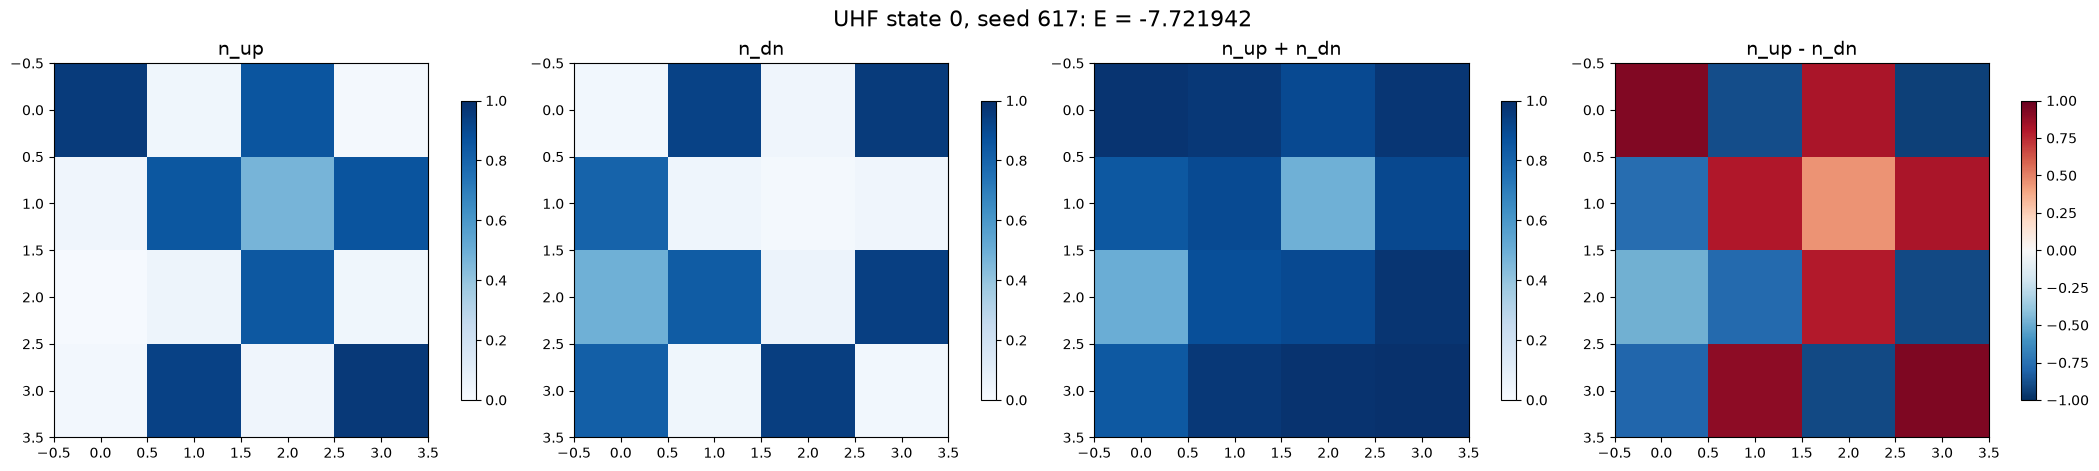

state 0: seed 617, E_UHF = -7.72194226 -> /Users/fnappi/Desktop/uhf_dmrg_4x4_U8/state_00


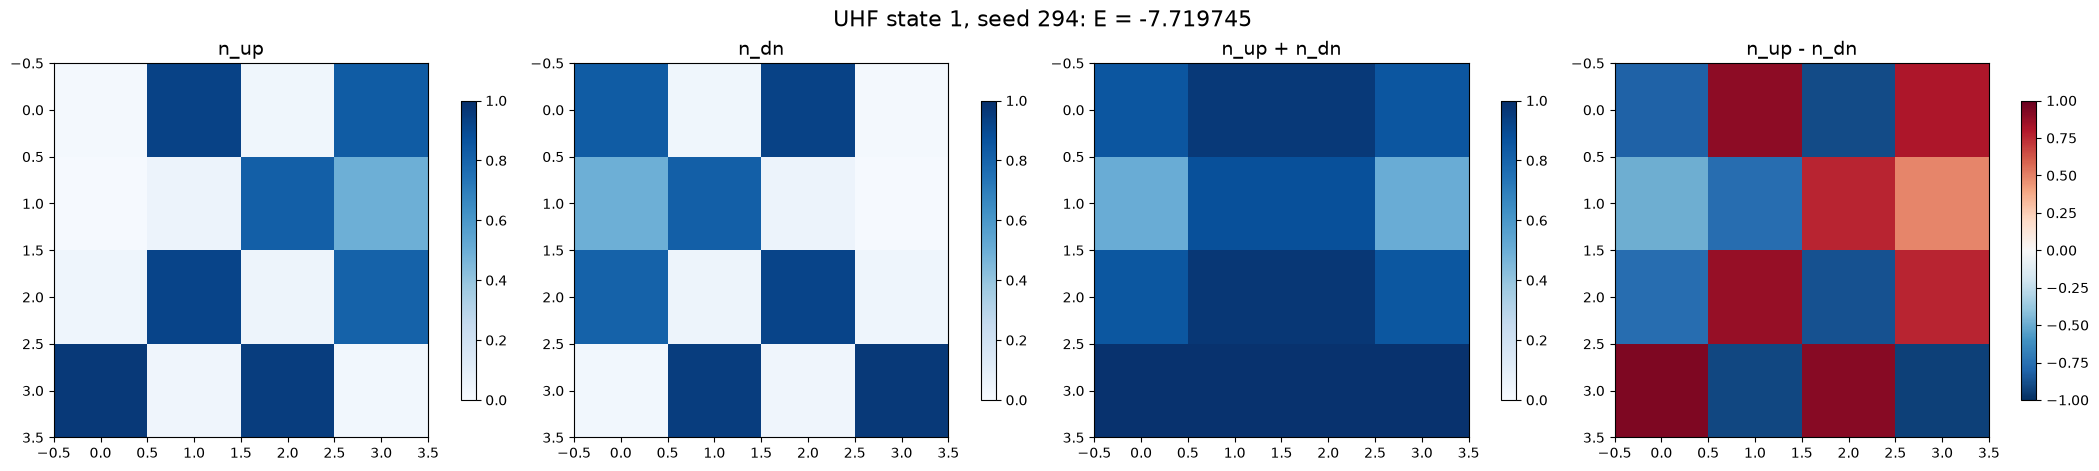

state 1: seed 294, E_UHF = -7.71974462 -> /Users/fnappi/Desktop/uhf_dmrg_4x4_U8/state_01


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt

out = Path.home() / "Desktop" / "uhf_dmrg_4x4_U8"
n_states = 2

chosen = []
for k in np.argsort(energies):
    if all(abs(energies[k] - energies[j]) > 1e-6 for j in chosen):
        chosen.append(int(k))
    if len(chosen) == n_states:
        break


def occupation_plot(rdm1, title, path):
    """n_up, n_dn, density, magnetization and staggered magnetization on the lattice, saved to path."""
    n_up_site, n_dn_site = (np.diag(rdm1[s]).reshape(L, L) for s in (0, 1))
    sign = (-1.0) ** np.add.outer(np.arange(L), np.arange(L))  # (-1)^(x+y), indexed [y, x]
    density = n_up_site + n_dn_site
    panels = [(n_up_site, "n_up", "Blues", 0.0, 1.0),
              (n_dn_site, "n_dn", "Blues", 0.0, 1.0),
              (density, "n_up + n_dn", "Blues", 0.0, max(1.0, density.max())),
              (n_up_site - n_dn_site, "n_up - n_dn", "RdBu_r", -1.0, 1.0),]
    fig, axes = plt.subplots(1, len(panels), figsize=(21, 4.6), layout="constrained")
    for ax, (values, name, cmap, vmin, vmax) in zip(axes, panels):
        image = ax.imshow(values, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(name, fontsize=14)
        fig.colorbar(image, ax=ax, shrink=0.8)
    fig.suptitle(title, fontsize=16)
    fig.savefig(path, dpi=120)
    plt.show()


for rank, k in enumerate(chosen):
    folder = out / f"state_{rank:02d}"
    folder.mkdir(parents=True, exist_ok=True)
    seed = int(seeds[k])
    np.random.seed(seed)
    np.save(folder / "guess.npy", np.random.rand(2, N, N))  # the same guess the loop used for this seed
    np.savez(folder / "uhf.npz", seed=seed, energy=energies[k], Ca=Cas[k], Cb=Cbs[k], rdm1=one_rdms[k])
    occupation_plot(one_rdms[k], f"UHF state {rank}, seed {seed}: E = {energies[k]:.6f}", folder / "uhf_occupations.png")
    print(f"state {rank}: seed {seed}, E_UHF = {energies[k]:.8f} -> {folder}")



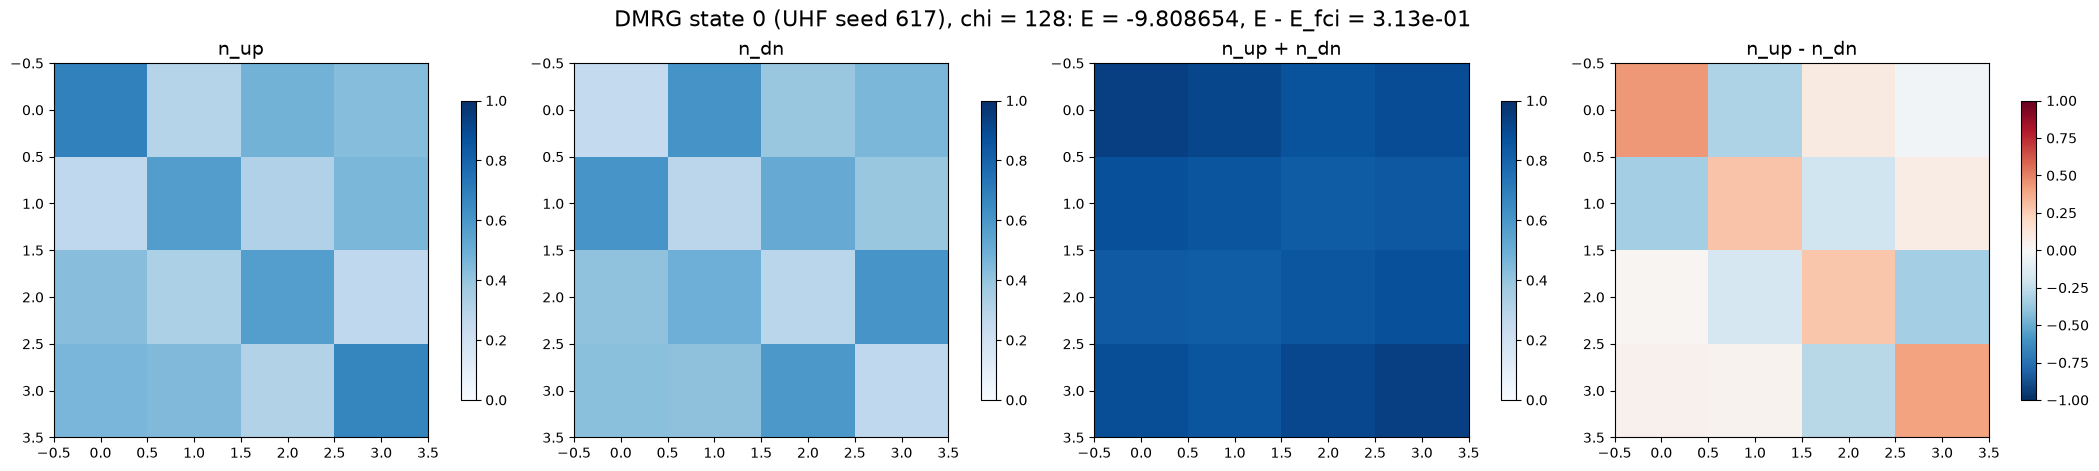

state 0: seed 617, chi 128, E_DMRG = -9.80865421s


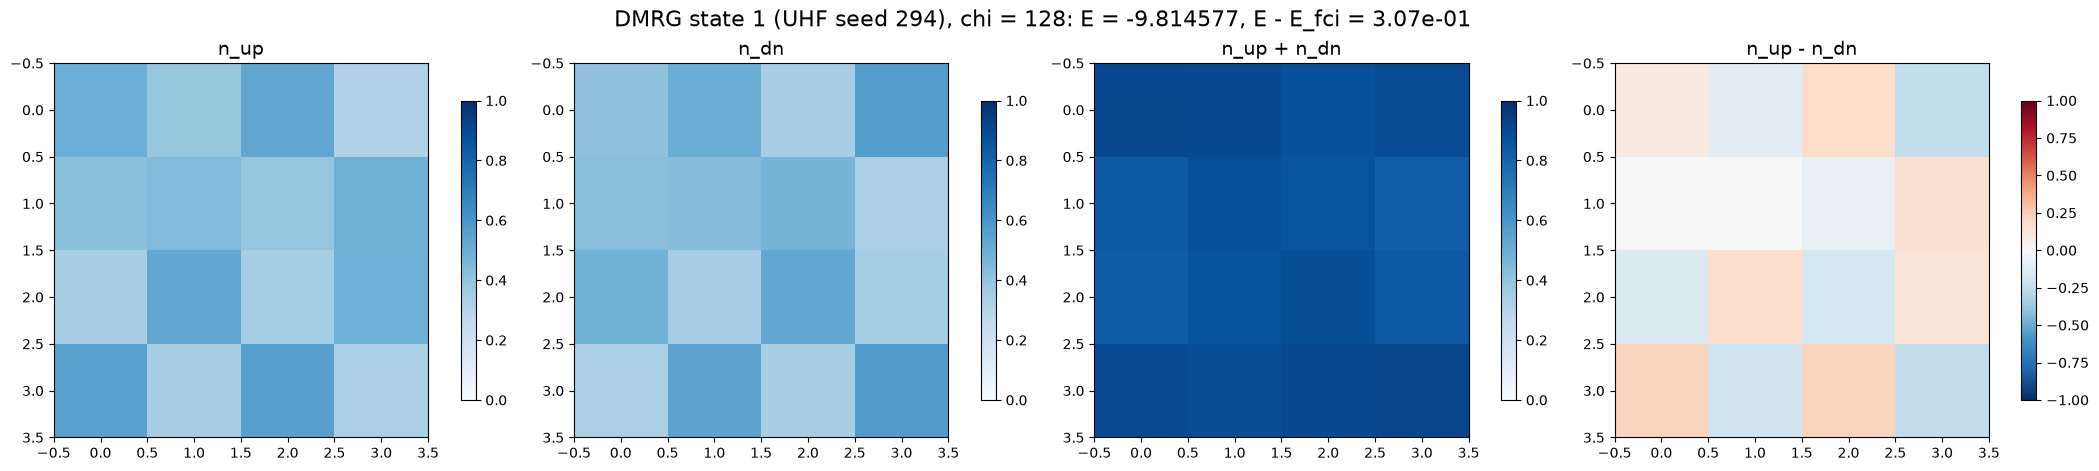

state 1: seed 294, chi 128, E_DMRG = -9.81457702s


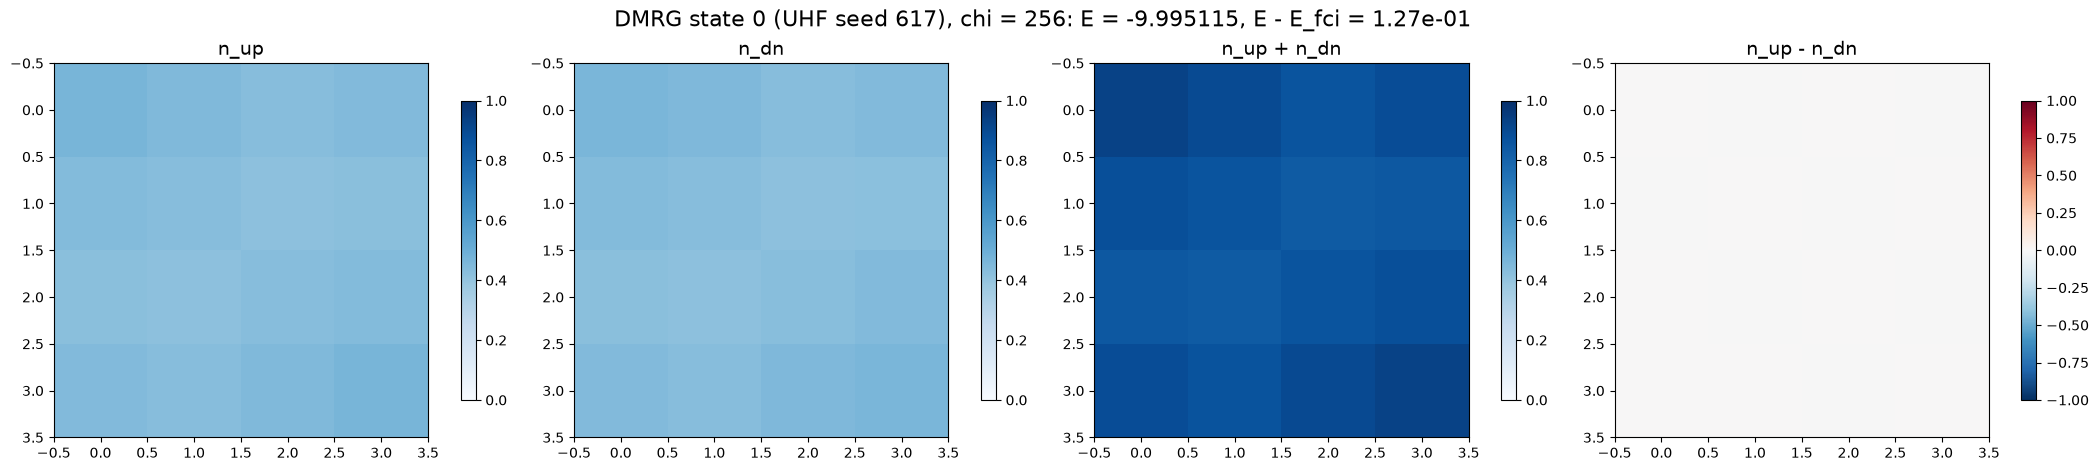

state 0: seed 617, chi 256, E_DMRG = -9.99511452s


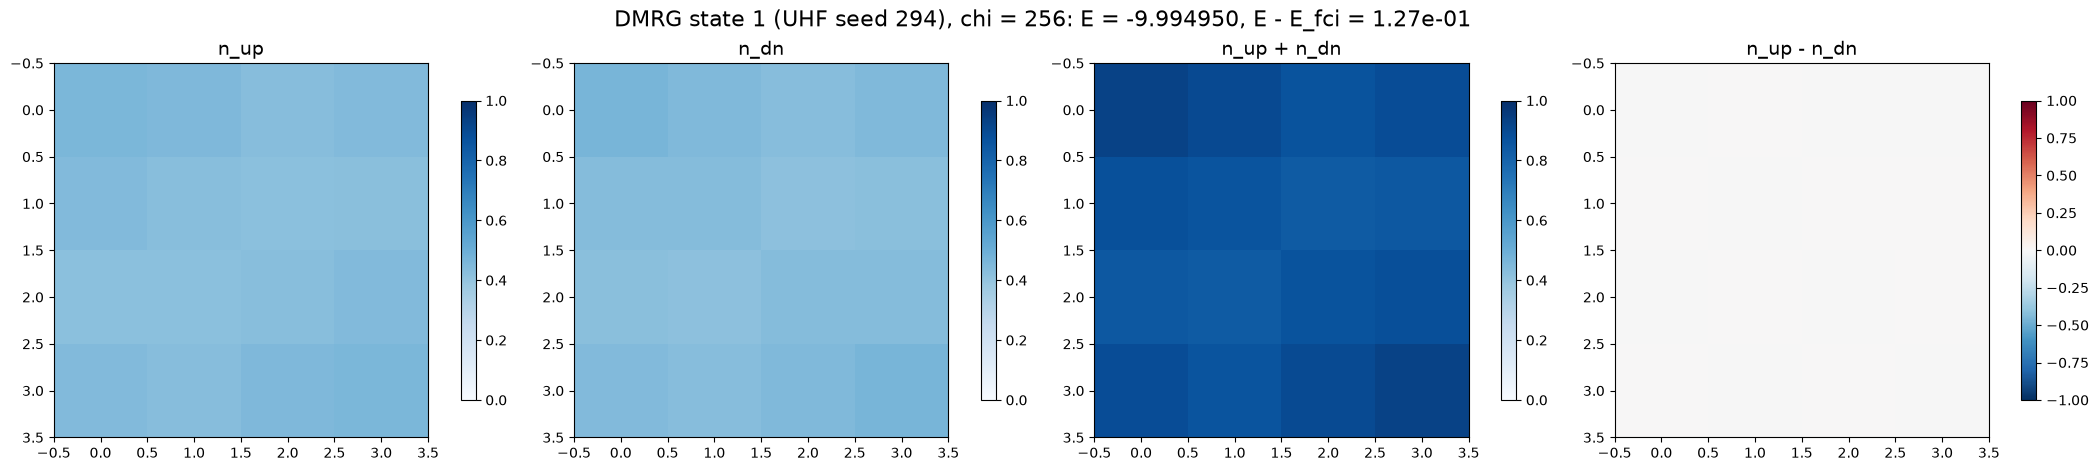

state 1: seed 294, chi 256, E_DMRG = -9.99495012s


KeyboardInterrupt: 

In [8]:
import contextlib
import ctypes
import os
import sys
import time
import warnings

from pyblock3.symbolic.expr import OpElement, OpNames
from pyblock3.symbolic.symbolic_mpo import SiteMPO

PHYSICAL = [(0, 0), (1, 0), (0, 1), (1, 1)]  # (n_up, n_dn) of the local states |0>, |up>, |dn>, |up dn>


def gmps_to_pyblock3(tensors, charges):
    """Dense charge-labelled site tensors (sd_to_gmps) as a flat pyblock3 SZ MPS."""
    q = lambda a, b: SZ(a + b, a - b, 0)
    out = []
    for A, q_left, q_right in zip(tensors, charges[:-1], charges[1:]):
        A, blocks = np.asarray(A), []
        for left in sorted(set(map(tuple, q_left))):
            rows = np.flatnonzero((q_left == left).all(axis=1))
            for p, (a, b) in enumerate(PHYSICAL):
                right = (left[0] + a, left[1] + b)
                cols = np.flatnonzero((q_right == right).all(axis=1))
                block = A[np.ix_(rows, [p], cols)]
                if np.any(block):
                    blocks.append(SubTensor(reduced=block, q_labels=(q(*left), q(a, b), q(*right))))
        out.append(SparseTensor(blocks=blocks))
    return MPS(tensors=out).to_flat()


@contextlib.contextmanager
def quiet():
    """Silence block3's 'MPO site ...' lines: compiled code writes them straight to file descriptor 1."""
    libc = ctypes.CDLL(None)
    sys.stdout.flush()
    libc.fflush(None)
    saved = os.dup(1)
    with open(os.devnull, "w") as null:
        os.dup2(null.fileno(), 1)
        try:
            yield
        finally:
            libc.fflush(None)
            os.dup2(saved, 1)
            os.close(saved)





def annihilator(i, s):

    op = OpElement(OpNames.D, (i, s), q_label=SZ(-1, -1 if s == 0 else 1, hamiltonian.orb_sym[i]))
    site = SiteMPO(hamiltonian, op)
    return MPS(tensors=site.tensors, const=0.0, dq=site.dq).to_sparse().to_flat()


def one_rdm(psi):
    """Spin-resolved 1-RDM <psi|c+_{i,s} c_{j,s}|psi> / <psi|psi> = <c_{i,s} psi|c_{j,s} psi> / <psi|psi>, as in the
    pyblock3 docs' 1-PDM example. s = 0 up, 1 down."""
    rdm, norm = np.zeros((2, N, N)), float(psi @ psi)
    with warnings.catch_warnings():  # pyblock3's quantum-number arithmetic overflows harmlessly for c's labels
        warnings.filterwarnings("ignore", "overflow encountered in scalar", RuntimeWarning)
        for s in (0, 1):
            kets = [annihilator(i, s) @ psi for i in range(N)]
            for i in range(N):
                for j in range(i, N):
                    rdm[s, i, j] = rdm[s, j, i] = float(np.dot(kets[i].conj(), kets[j])) / norm
    return rdm



hamiltonian = make_pyblock3_hamiltonian(h1, (n_up, n_dn))
with quiet():
    mpo = hubbard_pyblock3_mpo(hamiltonian, h1, U)
energy = lambda psi: float(MPE(psi, mpo, psi)[0:2].expectation) / float(psi @ psi)

chi_channel = 16
chi_trial = [128,256,512,1024]
n_sweeps = 20
dmrg_mps, rows = {}, []
for chi in chi_trial:
    for rank, k in enumerate(chosen):
        start = time.perf_counter()
        folder = out / f"state_{rank:02d}"
        seed = int(seeds[k])
        gmps = sd_to_gmps(Cas[k], Cbs[k], chi=chi_channel)
        mps = gmps_to_pyblock3(gmps.tensors, gmps.charges)
        e_start = energy(mps)
        np.random.seed(0)  # DMRG noise
        result = MPE(mps, mpo, mps).dmrg(bdims=[chi] * 6, noises=[1e-5] * 4 + [0.0] * 2, dav_thrds=[1e-9],
                                        iprint=-1, n_sweeps=n_sweeps)
        e_dmrg = energy(mps)
        rdm_dmrg = one_rdm(mps)
        # np.savez(folder / "dmrg.npz", energy=e_dmrg, sweep_energies=np.array([float(e) for e in result.energies]),
        #         rdm1=rdm_dmrg, chi=chi_trial, n_sweeps=n_sweeps, chi_channel=chi_channel, start_energy=e_start,
        #         gmps_discarded=gmps.discarded)
        occupation_plot(rdm_dmrg, f"DMRG state {rank} (UHF seed {seed}), chi = {chi}: E = {e_dmrg:.6f}, "
                                f"E - E_fci = {e_dmrg - E_fci:.2e}", folder / "dmrg_occupations.png")
        dmrg_mps[rank] = mps
        print(f"state {rank}: seed {seed}, chi {chi}, E_DMRG = {e_dmrg:.8f}s")
    

In [ ]:
from trot.gmps.utils import densify
from trot.meas.mps import hubbard_mpo_from_h1
from trot.trial.mps import rotate_spin, spin_rotation_y

R90 = spin_rotation_y(90)  # exp(-i pi/2 S^y), as run_mps_cpmc.py --trial-rotation 90 --rotated-trial as_is
W = hubbard_mpo_from_h1(h1, U)
SX = np.zeros((4, 4))
SX[1, 2] = SX[2, 1] = 0.5  # S^x_i = (c+_up c_dn + c+_dn c_up) / 2 in the local basis |0>, |up>, |dn>, |up dn>
LOCAL = (np.diag([0.0, 1.0, 0.0, 1.0]), np.diag([0.0, 0.0, 1.0, 1.0]), SX)  # n_up, n_dn, S^x on one site


def dense_expectations(tensors):
    """<H> and the on-site <n_up>, <n_dn>, <S^x> of a real d=4 MPS given as dense tensors (no (N_up, N_dn) labels
    needed), over <psi|psi>. Every contraction is a two-tensor tensordot."""
    left, right = [np.ones((1, 1))], [np.ones((1, 1))]
    for A in tensors:
        left.append(np.tensordot(np.tensordot(left[-1], A, (0, 0)), A, ([0, 1], [0, 1])))
    for A in tensors[::-1]:
        right.insert(0, np.tensordot(A, np.tensordot(A, right[0], (2, 1)), ([1, 2], [1, 2])))
    norm = left[-1].item()
    local = np.zeros((len(LOCAL), len(tensors)))
    for i, A in enumerate(tensors):
        for k, op in enumerate(LOCAL):
            X = np.tensordot(np.tensordot(left[i], A, (0, 0)), op, (1, 0))  # (b, c, q)
            local[k, i] = np.sum(np.tensordot(X, A, ([0, 2], [0, 1])) * right[i + 1]) / norm
    env = np.zeros((1, W.shape[1], 1))  # (bra, MPO channel, ket); channel 0 = nothing placed yet
    env[0, 0, 0] = 1.0
    for A, w in zip(tensors, W):
        env = np.tensordot(np.tensordot(np.tensordot(env, A, (0, 0)), w, ([0, 2], [0, 1])), A, ([0, 2], [0, 1]))
    return env[0, -1, 0] / norm, local  # last channel = finished terms


def moment_plot(sx, title, path):
    """<S^x_i> and the staggered (-1)^(x+y) <S^x_i> on the lattice, saved to path."""
    sign = (-1.0) ** np.add.outer(np.arange(L), np.arange(L))  # (-1)^(x+y), indexed [y, x]
    panels = [(sx.reshape(L, L), "<S^x_i>"), (sign * sx.reshape(L, L), "(-1)^(x+y) <S^x_i>")]
    fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.6), layout="constrained")
    for ax, (values, name) in zip(axes, panels):
        image = ax.imshow(values, cmap="RdBu_r", vmin=-0.5, vmax=0.5)
        ax.set_title(name, fontsize=14)
        fig.colorbar(image, ax=ax, shrink=0.8)
    fig.suptitle(title, fontsize=16)
    fig.savefig(path, dpi=120)
    plt.show()


for rank, k in enumerate(chosen):
    folder = out / f"state_{rank:02d}"
    rotated = rotate_spin(densify(dmrg_mps[rank]).tensors, R90)  # site by site: bonds unchanged, N_up and N_dn mixed
    e_rot, (occ_up, occ_dn, sx) = dense_expectations(rotated)
    np.savez(folder / "dmrg_rotated_asis.npz", energy=e_rot, n_up=occ_up, n_dn=occ_dn, sx=sx, R=R90)
    title = f"Spin projected DMRG state {rank} : E = {e_rot:.6f}"
    occupation_plot(np.array([np.diag(occ_up), np.diag(occ_dn)]), title, folder / "dmrg_rotated_asis_occupations.png")
    # moment_plot(sx, title, folder / "dmrg_rotated_asis_sx.png")
    # print(f"state {rank}: seed {int(seeds[k])}, rotated E {e_rot:.8f}, max |<S^x_i>| {abs(sx).max():.3f}", flush=True)

NameError: name 'h1' is not defined